<a href="https://colab.research.google.com/github/BintangPancahaya/PemMes_2026/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
data.info()
print(data.isnull().sum().sum(), 'missing value')
data['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,count
label,
male,1584
female,1584


meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
centroid    0.337415
meanfreq    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label_num, dtype: float64


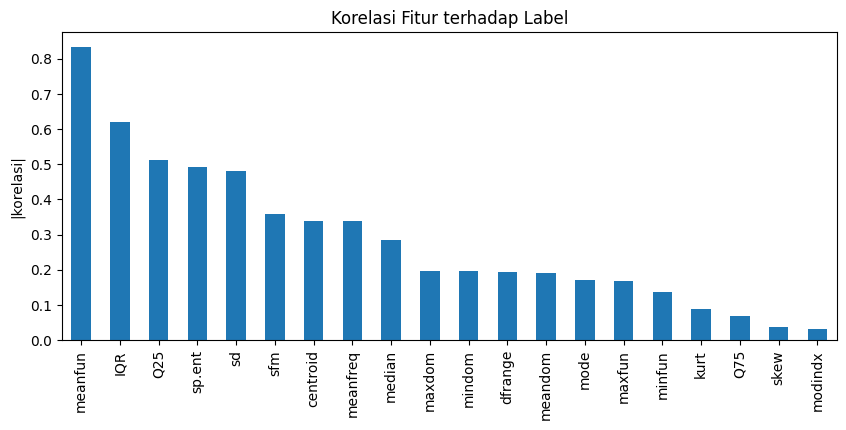

In [3]:
import matplotlib.pyplot as plt

# ubah label menjadi angka supaya bisa dihitung korelasinya
data['label_num'] = data['label'].map({'male': 0, 'female': 1})

# korelasi setiap fitur dengan label (nilai absolut), diurutkan dari yang terbesar
korelasi = data.drop(columns='label').corr()['label_num'].drop('label_num').abs()
korelasi = korelasi.sort_values(ascending=False)
print(korelasi)

korelasi.plot(kind='bar', figsize=(10, 4))
plt.title('Korelasi Fitur terhadap Label')
plt.ylabel('|korelasi|')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = data.drop(columns=['label', 'label_num'])   # semua fitur
y = data['label']

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardisasi
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Model kNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)
print('Akurasi (20 fitur):', accuracy_score(y_test, y_pred))

Akurasi (20 fitur): 0.9737118822292324


1 fitur -> akurasi 0.9527
2 fitur -> akurasi 0.9769
3 fitur -> akurasi 0.979
4 fitur -> akurasi 0.98
5 fitur -> akurasi 0.9821
6 fitur -> akurasi 0.9832
7 fitur -> akurasi 0.9832
8 fitur -> akurasi 0.9832
9 fitur -> akurasi 0.9832
10 fitur -> akurasi 0.9811
11 fitur -> akurasi 0.9811
12 fitur -> akurasi 0.979
13 fitur -> akurasi 0.979
14 fitur -> akurasi 0.979
15 fitur -> akurasi 0.979
16 fitur -> akurasi 0.98
17 fitur -> akurasi 0.98
18 fitur -> akurasi 0.9748
19 fitur -> akurasi 0.9758
20 fitur -> akurasi 0.9737


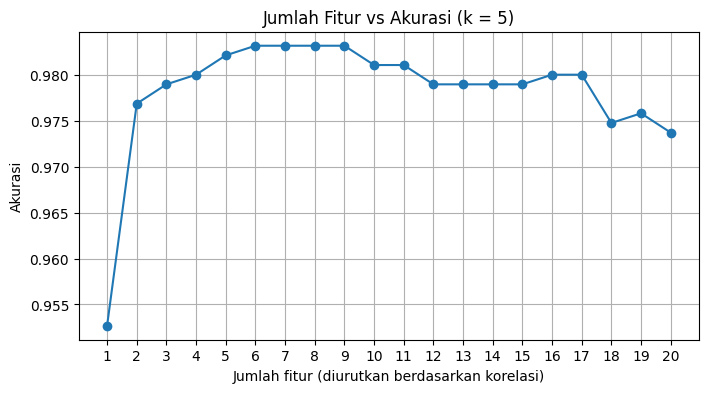

In [5]:
urutan_fitur = korelasi.index.tolist()

jumlah_fitur = []
akurasi_fitur = []

for n in range(1, 21):
    fitur = urutan_fitur[:n]

    X_n = data[fitur]
    Xtr, Xte, ytr, yte = train_test_split(X_n, y, test_size=0.3, random_state=42, stratify=y)

    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(Xtr, ytr)

    jumlah_fitur.append(n)
    akurasi_fitur.append(model.score(Xte, yte))
    print(n, 'fitur -> akurasi', round(akurasi_fitur[-1], 4))

plt.figure(figsize=(8, 4))
plt.plot(jumlah_fitur, akurasi_fitur, marker='o')
plt.title('Jumlah Fitur vs Akurasi (k = 5)')
plt.xlabel('Jumlah fitur (diurutkan berdasarkan korelasi)')
plt.ylabel('Akurasi')
plt.xticks(jumlah_fitur)
plt.grid(True)
plt.show()

In [6]:
n_terbaik = jumlah_fitur[akurasi_fitur.index(max(akurasi_fitur))]
fitur_terbaik = urutan_fitur[:n_terbaik]

print('Jumlah fitur terbaik :', n_terbaik)
print('Akurasi tertinggi    :', max(akurasi_fitur))
print('Fitur yang dipakai   :', fitur_terbaik)

Jumlah fitur terbaik : 6
Akurasi tertinggi    : 0.9831756046267087
Fitur yang dipakai   : ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm']


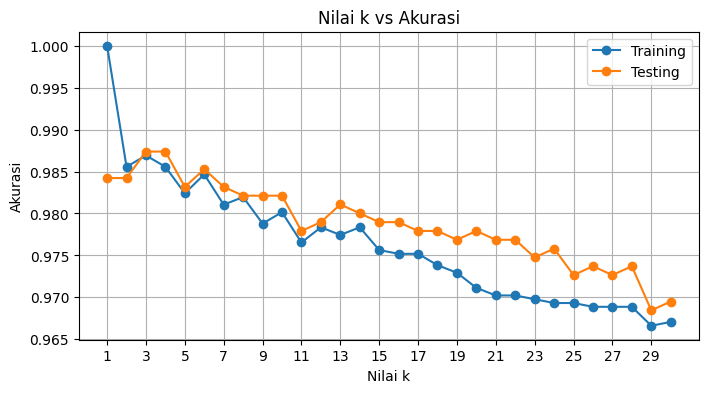

In [7]:
X = data[fitur_terbaik]
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

acc_train = []
acc_test = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc_train.append(model.score(X_train, y_train))
    acc_test.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), acc_train, marker='o', label='Training')
plt.plot(range(1, 31), acc_test, marker='o', label='Testing')
plt.title('Nilai k vs Akurasi')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(True)
plt.show()

In [8]:
k_terbaik = acc_test.index(max(acc_test)) + 1
print('k terbaik        :', k_terbaik)
print('Akurasi testing  :', max(acc_test))
print('Akurasi training :', acc_train[k_terbaik - 1])

k terbaik        : 3
Akurasi testing  : 0.9873817034700315
Akurasi training : 0.9869192602616148


In [9]:
from sklearn.metrics import confusion_matrix, classification_report

knn_final = KNeighborsClassifier(n_neighbors=k_terbaik)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

print('Akurasi:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred))

Akurasi: 0.9873817034700315
Confusion Matrix:
 [[470   6]
 [  6 469]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.99      0.99      0.99       476
        male       0.99      0.99      0.99       475

    accuracy                           0.99       951
   macro avg       0.99      0.99      0.99       951
weighted avg       0.99      0.99      0.99       951

